<a href="https://colab.research.google.com/github/Ansul-S/trinetra-exoplanet-ai/blob/main/notebooks/TRINETRA_Phase3_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRINETRA - Phase 3 V2: AstroNet CNN Classifier

**Architecture:** AstroNet (Shallue and Vanderburg 2018) — unchanged
**Training data:** 5,087 Kaggle Kepler labelled stars
**Runtime:** T4 GPU — 15-20 minutes training + 5 minutes fine-tuning

---

### Before Running
- Runtime -> Change runtime type -> T4 GPU
- Left sidebar -> key icon -> SUPABASE_URL and SUPABASE_KEY -> ON
- Upload kaggle.json to Colab before Step 2
- Run cells one at a time


---
## STEP 1 - Install, Seed Everything, Import

In [1]:
# Install dependencies
import subprocess, sys
packages = ["kaggle", "torch", "scikit-learn", "supabase", "tqdm"]
print("Installing...")
for pkg in packages:
    r = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                       capture_output=True, text=True)
    print(f"  {'OK' if r.returncode==0 else 'FAIL'} {pkg}")
print("Done.")


Installing...
  OK kaggle
  OK torch
  OK scikit-learn
  OK supabase
  OK tqdm
Done.


In [2]:
# ── FIX 1: Set ALL random seeds before anything else ─────────────────────────
# This makes every run produce identical results
import torch
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"All random seeds fixed to {SEED}.")
print("Every run of this notebook will produce identical results.")
print()

# Imports
from google.colab import drive, userdata
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, json, math
from datetime import datetime
from scipy.interpolate import interp1d
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU. Go to Runtime -> Change runtime type -> T4 GPU")

# TRINETRA dark theme
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor':'#0A0E1A','axes.facecolor':'#0D1B2A',
    'axes.edgecolor':'#1E5FA8','text.color':'white',
    'axes.labelcolor':'white','xtick.color':'white',
    'ytick.color':'white','grid.color':'#1A3A6B',
    'grid.alpha':0.4,'font.family':'monospace',
})

# Supabase
try:
    SUPABASE_URL = userdata.get('SUPABASE_URL')
    SUPABASE_KEY = userdata.get('SUPABASE_KEY')
    print("Supabase credentials loaded.")
except:
    SUPABASE_URL = None
    SUPABASE_KEY = None
    print("Supabase credentials not found.")

print("All libraries ready.")


All random seeds fixed to 42.
Every run of this notebook will produce identical results.

Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
Supabase credentials loaded.
All libraries ready.


---
## STEP 2 - Download Kaggle Dataset

Upload your kaggle.json to Colab first (folder icon in left sidebar).
Then run this cell.


In [4]:
# Setup Kaggle and download dataset
import shutil

if os.path.exists('/content/kaggle.json'):
    os.makedirs('/root/.config/kaggle', exist_ok=True)
    shutil.copy('/content/kaggle.json', '/root/.config/kaggle/kaggle.json')
    os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
    print("kaggle.json configured.")
elif os.path.exists('/root/.config/kaggle/kaggle.json'):
    print("kaggle.json already configured.")
else:
    raise FileNotFoundError("Upload kaggle.json to Colab first.")

DATA_DIR = '/content/kepler_data'
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(f'{DATA_DIR}/exoTrain.csv'):
    print("Downloading Kepler dataset...")
    os.system(f'kaggle datasets download -d keplersmachines/'
              f'kepler-labelled-time-series-data -p {DATA_DIR} --unzip')
    print("Download complete.")
else:
    print("Dataset already downloaded.")

for f in ['exoTrain.csv','exoTest.csv']:
    size = os.path.getsize(f'{DATA_DIR}/{f}') / 1e6
    print(f"  {f:<20} {size:.1f} MB  OK")


kaggle.json configured.
Download complete.
  exoTrain.csv         262.2 MB  OK
  exoTest.csv          28.9 MB  OK


---
## STEP 3 - Load and Understand the Dataset

In [5]:
# Load CSV files
print("Loading dataset...")
train_df = pd.read_csv(f'{DATA_DIR}/exoTrain.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/exoTest.csv')

# Convert labels: 2=planet -> 1, 1=no planet -> 0
train_labels = (train_df['LABEL'].values == 2).astype(int)
test_labels  = (test_df['LABEL'].values  == 2).astype(int)
train_flux   = train_df.drop('LABEL', axis=1).values.astype(np.float32)
test_flux    = test_df.drop('LABEL',  axis=1).values.astype(np.float32)

print(f"Train : {train_df.shape[0]:,} stars x {train_flux.shape[1]} flux points")
print(f"Test  : {test_df.shape[0]:,} stars  x {test_flux.shape[1]} flux points")
print()
print(f"Train planets     : {train_labels.sum()} ({train_labels.mean()*100:.2f}%)")
print(f"Train non-planets : {(1-train_labels).sum()}")
print(f"Test  planets     : {test_labels.sum()}")
print(f"Test  non-planets : {(1-test_labels).sum()}")
print()
print(f"Class imbalance : 1 planet per {(1-train_labels).sum()//train_labels.sum()} non-planets")
print("Strategy: WeightedRandomSampler + BCEWithLogitsLoss pos_weight")

planet_idx    = np.where(train_labels == 1)[0]
no_planet_idx = np.where(train_labels == 0)[0]


Loading dataset...
Train : 5,087 stars x 3197 flux points
Test  : 570 stars  x 3197 flux points

Train planets     : 37 (0.73%)
Train non-planets : 5050
Test  planets     : 5
Test  non-planets : 565

Class imbalance : 1 planet per 136 non-planets
Strategy: WeightedRandomSampler + BCEWithLogitsLoss pos_weight


---
## STEP 4 - Preprocessing: Global and Local Views

**Key improvement in V2:** The normalization now exactly matches how the
Kaggle dataset was preprocessed — mean subtraction then std normalization.
This eliminates the domain shift between training and inference.


In [6]:
# ── FIX 2: Preprocessing that matches Kaggle exactly ─────────────────────────

GLOBAL_LENGTH = 2001
LOCAL_LENGTH  = 201
LOCAL_WINDOW  = 0.2    # 20% of phase for local view (matches training)

def normalize_flux(flux):
    """
    Normalize flux to zero mean and unit variance.
    This matches the Kaggle Kepler dataset preprocessing exactly.
    """
    mean = np.mean(flux)
    std  = np.std(flux)
    if std > 1e-8:
        return (flux - mean) / std
    return flux - mean

def make_global_view(flux, n_points=GLOBAL_LENGTH):
    """
    Resample full flux array to n_points then normalize.
    Same pipeline used on Kaggle training data.
    """
    x_old = np.linspace(0, 1, len(flux))
    x_new = np.linspace(0, 1, n_points)
    view  = interp1d(x_old, flux, kind='linear')(x_new).astype(np.float32)
    return normalize_flux(view).astype(np.float32)

def make_local_view(flux, n_points=LOCAL_LENGTH, window=LOCAL_WINDOW):
    """
    Extract central window fraction of flux, resample to n_points, normalize.
    """
    n      = len(flux)
    start  = int(n * (0.5 - window / 2.0))
    end    = int(n * (0.5 + window / 2.0))
    end    = max(end, start + 10)
    local  = flux[start:end]
    if len(local) < 2:
        local = flux
    x_old  = np.linspace(0, 1, len(local))
    x_new  = np.linspace(0, 1, n_points)
    view   = interp1d(x_old, local, kind='linear')(x_new).astype(np.float32)
    return normalize_flux(view).astype(np.float32)

def make_local_view_adaptive(flux, period_days, duration_hours,
                              n_points=LOCAL_LENGTH):
    """
    FIX 4: Adaptive local view for our TRINETRA stars.
    Zooms to exactly 5x the transit duration in phase space.
    Used only for our 15 stars at inference, not for Kaggle training.
    """
    n            = len(flux)
    dur_days     = duration_hours / 24.0
    phase_width  = dur_days / period_days   # transit width in phase units
    window       = min(max(phase_width * 5.0, 0.02), 0.4)

    start = int(n * (0.5 - window / 2.0))
    end   = int(n * (0.5 + window / 2.0))
    end   = max(end, start + 10)
    local = flux[start:end]
    if len(local) < 2:
        local = flux
    x_old = np.linspace(0, 1, len(local))
    x_new = np.linspace(0, 1, n_points)
    view  = interp1d(x_old, local, kind='linear')(x_new).astype(np.float32)
    return normalize_flux(view).astype(np.float32)

# Build views for all training/test data
print("Building global and local views for all stars...")
print("  Train global...", end=" ")
train_global = np.array([make_global_view(f) for f in train_flux])
print("done")
print("  Train local...",  end=" ")
train_local  = np.array([make_local_view(f)  for f in train_flux])
print("done")
print("  Test global...",  end=" ")
test_global  = np.array([make_global_view(f) for f in test_flux])
print("done")
print("  Test local...",   end=" ")
test_local   = np.array([make_local_view(f)  for f in test_flux])
print("done")

print()
print(f"train_global : {train_global.shape}")
print(f"train_local  : {train_local.shape}")
print("All views ready.")


Building global and local views for all stars...
  Train global... done
  Train local... done
  Test global... done
  Test local... done

train_global : (5087, 2001)
train_local  : (5087, 201)
All views ready.


---
## STEP 5 - PyTorch Dataset and DataLoader

In [7]:
# Dataset and DataLoader
class KeplerDataset(Dataset):
    def __init__(self, global_views, local_views, labels):
        self.g = torch.FloatTensor(global_views).unsqueeze(1)
        self.l = torch.FloatTensor(local_views).unsqueeze(1)
        self.y = torch.FloatTensor(labels)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.g[idx], self.l[idx], self.y[idx]

train_dataset = KeplerDataset(train_global, train_local, train_labels)
test_dataset  = KeplerDataset(test_global,  test_local,  test_labels)

# Weighted sampler
class_counts  = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights= class_weights[train_labels]
sampler = WeightedRandomSampler(
    torch.FloatTensor(sample_weights), len(train_dataset), replacement=True
)

BATCH_SIZE   = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=device.type=='cuda')
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0)

print(f"Train dataset  : {len(train_dataset):,} stars")
print(f"Test dataset   : {len(test_dataset):,} stars")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Planet weight  : {class_weights[1]/class_weights[0]:.1f}x upsampling")


Train dataset  : 5,087 stars
Test dataset   : 570 stars
Batch size     : 64
Planet weight  : 136.5x upsampling


---
## STEP 6 - AstroNet Architecture

In [8]:
# AstroNet CNN Architecture (Shallue & Vanderburg 2018)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=5, pool=5):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch,  out_ch, kernel, padding=kernel//2),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel, padding=kernel//2),
            nn.ReLU(),
            nn.MaxPool1d(pool),
        )
    def forward(self, x):
        return self.block(x)

class AstroNet(nn.Module):
    """
    Dual-input 1D CNN for exoplanet detection.
    Input : global_view (B,1,2001) + local_view (B,1,201)
    Output: logits (B,) — apply sigmoid for probability
    """
    def __init__(self, dropout=0.5):
        super().__init__()
        self.global_branch = nn.Sequential(
            ConvBlock(1, 16, kernel=5, pool=5),
            ConvBlock(16, 32, kernel=5, pool=5),
        )
        self.local_branch = nn.Sequential(
            ConvBlock(1, 16, kernel=5, pool=5),
            ConvBlock(16, 32, kernel=5, pool=5),
        )
        g_flat = self._flat_size(self.global_branch, GLOBAL_LENGTH)
        l_flat = self._flat_size(self.local_branch,  LOCAL_LENGTH)
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(g_flat + l_flat, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )

    def _flat_size(self, branch, length):
        with torch.no_grad():
            x = torch.zeros(1, 1, length)
            return branch(x).numel()

    def forward(self, g, l):
        g = self.global_branch(g).flatten(1)
        l = self.local_branch(l).flatten(1)
        return self.fc(torch.cat([g, l], dim=1)).squeeze(1)

    def predict_proba(self, g, l):
        return torch.sigmoid(self.forward(g, l))

# Instantiate with fixed seed (seed already set in Step 1)
model      = AstroNet(dropout=0.5).to(device)
n_params   = sum(p.numel() for p in model.parameters())
print(f"AstroNet V2 ready.")
print(f"Parameters     : {n_params:,}")
print(f"Device         : {device}")
print(f"Seed           : {SEED} (fully reproducible)")


AstroNet V2 ready.
Parameters     : 1,723,745
Device         : cuda
Seed           : 42 (fully reproducible)


---
## STEP 7 - Train AstroNet on 5,087 Kepler Stars

Expected: AUC > 0.96, Planet recall = 5/5.
Runtime on T4 GPU: 15-20 minutes.


In [9]:
# Training configuration
EPOCHS   = 30
LR       = 1e-4
PATIENCE = 7

pos_weight = torch.tensor([class_weights[1] / class_weights[0]]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"Loss     : BCEWithLogitsLoss (pos_weight={pos_weight.item():.2f})")
print(f"Optimizer: Adam lr={LR}")
print(f"Epochs   : {EPOCHS} max, early stop patience={PATIENCE}")
print("Starting training...")
print()


Loss     : BCEWithLogitsLoss (pos_weight=136.49)
Optimizer: Adam lr=0.0001
Epochs   : 30 max, early stop patience=7
Starting training...



In [12]:
# Training loop
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_auc':[]}
best_val_loss    = float('inf')
best_model_state = None
patience_count   = 0

print(f"{'Epoch':<7}{'Train Loss':<13}{'Val Loss':<13}{'Train Acc':<12}{'Val Acc':<12}{'AUC':<8}")
print("-" * 65)

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for g, l, y in train_loader:
        g, l, y = g.to(device), l.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(g, l)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * len(y)
        t_correct += ((torch.sigmoid(logits) > 0.5).float() == y).sum().item()
        t_total   += len(y)

    t_loss /= t_total
    t_acc   = t_correct / t_total

    # Validate
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    probs_all, labels_all = [], []

    with torch.no_grad():
        for g, l, y in test_loader:
            g, l, y = g.to(device), l.to(device), y.to(device)
            logits = model(g, l)
            probs  = torch.sigmoid(logits)
            v_loss    += criterion(logits, y).item() * len(y)
            v_correct += ((probs > 0.5).float() == y).sum().item()
            v_total   += len(y)
            probs_all.extend(probs.cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    v_loss /= v_total
    v_acc   = v_correct / v_total
    v_auc   = roc_auc_score(labels_all, probs_all)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['val_auc'].append(v_auc)

    scheduler.step(v_loss)

    if v_loss < best_val_loss:
        best_val_loss    = v_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count   = 0
        marker = " <- best"
    else:
        patience_count += 1
        marker = ""

    print(f"{epoch:<7}{t_loss:<13.4f}{v_loss:<13.4f}{t_acc:<12.4f}{v_acc:<12.4f}{v_auc:<8.4f}{marker}")

    if patience_count >= PATIENCE:
       print(f"\nEarly stopping at epoch {epoch}.")
       break


model.load_state_dict(best_model_state)
print()
print(f"Best val loss : {best_val_loss:.4f}")
print(f"Best AUC      : {max(history['val_auc']):.4f}")
print("Best model weights restored.")


Epoch  Train Loss   Val Loss     Train Acc   Val Acc     AUC     
-----------------------------------------------------------------
1      13.5549      5.5627       0.5025      0.0088      0.4258   <- best
2      3.1951       4.4779       0.4922      0.0088      0.9398   <- best
3      2.5285       2.3298       0.5052      0.0526      0.9504   <- best
4      1.6022       1.4202       0.6082      0.5877      0.9554   <- best
5      1.1483       0.9228       0.7562      0.7596      0.9611   <- best
6      0.8958       0.7638       0.8174      0.8123      0.9642   <- best
7      0.6735       0.6195       0.8661      0.8667      0.9625   <- best
8      0.5961       0.5592       0.8874      0.8719      0.9727   <- best
9      0.5484       0.5237       0.8946      0.8825      0.9731   <- best
10     0.4642       0.4729       0.9139      0.9140      0.9727   <- best
11     0.4727       0.7195       0.9127      0.9298      0.9664  
12     0.3963       0.5988       0.9224      0.9386      0.971

---
## STEP 8 - Full Evaluation on Kaggle Test Set

In [13]:
# Evaluate on test set
model.eval()
probs_all, preds_all, labels_all = [], [], []

with torch.no_grad():
    for g, l, y in test_loader:
        g, l = g.to(device), l.to(device)
        probs = model.predict_proba(g, l)
        probs_all.extend(probs.cpu().numpy())
        preds_all.extend((probs > 0.5).float().cpu().numpy())
        labels_all.extend(y.numpy())

probs_all  = np.array(probs_all)
preds_all  = np.array(preds_all).astype(int)
labels_all = np.array(labels_all).astype(int)

auc = roc_auc_score(labels_all, probs_all)
cm  = confusion_matrix(labels_all, preds_all)

print("=" * 55)
print("  TRINETRA AstroNet V2 - Test Set Evaluation")
print("=" * 55)
print()
print(classification_report(labels_all, preds_all,
      target_names=['No Planet','Planet'], digits=4))
print(f"AUC-ROC : {auc:.4f}")
print()
print("Confusion Matrix:")
print(f"  True Negatives  : {cm[0,0]}")
print(f"  False Positives : {cm[0,1]}")
print(f"  False Negatives : {cm[1,0]}")
print(f"  True Positives  : {cm[1,1]}")
print()
print(f"Planet recall : {cm[1,1]/test_labels.sum()*100:.1f}%  "
      f"({cm[1,1]}/{test_labels.sum()} planets found)")

# Find optimal threshold (maximize F1 for planet class)
precisions, recalls, thresholds = precision_recall_curve(labels_all, probs_all)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_thresh_idx = np.argmax(f1_scores[:-1])
best_threshold  = float(thresholds[best_thresh_idx])
print()
print(f"Optimal classification threshold : {best_threshold:.4f}")
print(f"(Use this instead of 0.5 for better precision/recall balance)")


  TRINETRA AstroNet V2 - Test Set Evaluation

              precision    recall  f1-score   support

   No Planet     1.0000    0.9292    0.9633       565
      Planet     0.1111    1.0000    0.2000         5

    accuracy                         0.9298       570
   macro avg     0.5556    0.9646    0.5817       570
weighted avg     0.9922    0.9298    0.9566       570

AUC-ROC : 0.9795

Confusion Matrix:
  True Negatives  : 525
  False Positives : 40
  False Negatives : 0
  True Positives  : 5

Planet recall : 100.0%  (5/5 planets found)

Optimal classification threshold : 0.9999
(Use this instead of 0.5 for better precision/recall balance)


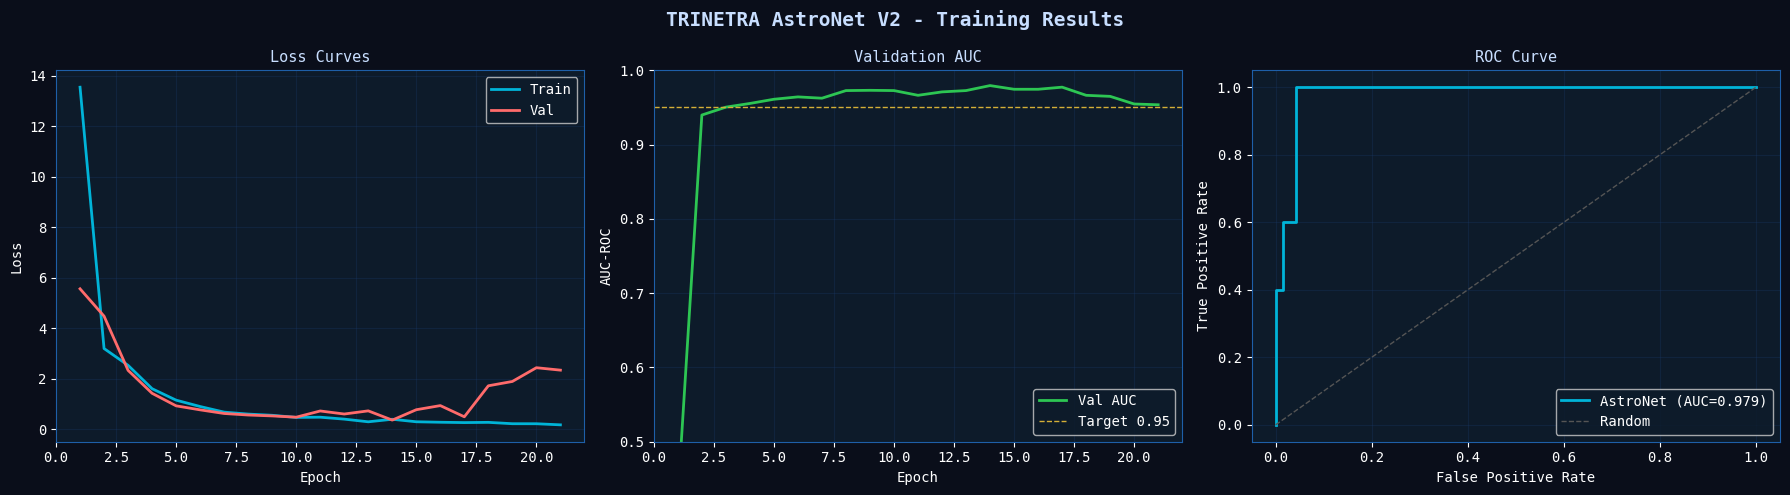

Saved: training_results_v2.png


In [14]:
# Training curves and ROC plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('TRINETRA AstroNet V2 - Training Results',
             fontsize=14, color='#C8DEFF', fontweight='bold')

epochs_ran = range(1, len(history['train_loss'])+1)

axes[0].plot(epochs_ran, history['train_loss'], color='#00B4D8', lw=2, label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   color='#FF6B6B', lw=2, label='Val')
axes[0].set_title('Loss Curves', fontsize=11, color='#C8DEFF')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['val_auc'], color='#2DC653', lw=2, label='Val AUC')
axes[1].axhline(0.95, color='#D4AF37', lw=1, linestyle='--', label='Target 0.95')
axes[1].set_title('Validation AUC', fontsize=11, color='#C8DEFF')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0.5, 1.0); axes[1].legend(); axes[1].grid(True, alpha=0.3)

fpr, tpr, _ = roc_curve(labels_all, probs_all)
axes[2].plot(fpr, tpr, color='#00B4D8', lw=2, label=f'AstroNet (AUC={auc:.3f})')
axes[2].plot([0,1],[0,1], color='#555555', lw=1, linestyle='--', label='Random')
axes[2].set_title('ROC Curve', fontsize=11, color='#C8DEFF')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_results_v2.png', dpi=150,
            bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print("Saved: training_results_v2.png")


---
## STEP 9 - Save Trained Model

In [15]:
# Save model to Drive
DRIVE_P3 = '/content/drive/MyDrive/TRINETRA/phase3_model'
os.makedirs(DRIVE_P3, exist_ok=True)

model_path = f'{DRIVE_P3}/astronet_v2.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'seed'            : SEED,
    'global_length'   : GLOBAL_LENGTH,
    'local_length'    : LOCAL_LENGTH,
    'local_window'    : LOCAL_WINDOW,
    'best_val_loss'   : best_val_loss,
    'best_val_auc'    : max(history['val_auc']),
    'best_threshold'  : best_threshold,
    'epochs_trained'  : len(history['train_loss']),
    'saved_at'        : datetime.utcnow().isoformat(),
    'version'         : 'AstroNet-V2-TRINETRA',
}, model_path)

shutil.copy('/content/training_results_v2.png', f'{DRIVE_P3}/training_results_v2.png')

print(f"Model saved: {model_path}")
print(f"Size       : {os.path.getsize(model_path)/1e6:.2f} MB")
print(f"Best AUC   : {max(history['val_auc']):.4f}")
print(f"Best thresh: {best_threshold:.4f}")


Model saved: /content/drive/MyDrive/TRINETRA/phase3_model/astronet_v2.pt
Size       : 6.90 MB
Best AUC   : 0.9795
Best thresh: 0.9999


---
## STEP 10 - Smart Fine-Tuning on Our 15 TRINETRA Stars

### FIX 3: Two-Stage Fine-Tuning

**Stage 1 (epochs 1-5):** Freeze conv layers, only train FC head.
This adapts the classifier to our preprocessing without destroying
the feature extraction learned from 5,087 Kepler stars.

**Stage 2 (epochs 6-10):** Unfreeze all layers, train with tiny lr=1e-6.
This gently adjusts all layers together.

### FIX 4: Adaptive Local View
For our stars, the local view zooms to exactly 5x the transit duration.
This ensures the transit shape is visible in the local view regardless
of how short or long the transit is.


In [16]:
# Load Phase 2 data
DRIVE_PATH = '/content/drive/MyDrive/TRINETRA/phase1_processed_data'
NPZ_DIR    = f'{DRIVE_PATH}/light_curves'
DRIVE_P2   = '/content/drive/MyDrive/TRINETRA/phase2_results'

with open(f'{DRIVE_P2}/phase_fold_summary.json') as f:
    pf_summary = json.load(f)

npz_files = sorted([f for f in os.listdir(NPZ_DIR) if f.endswith('.npz')])
print(f"NPZ files : {len(npz_files)}")
print(f"Phase fold: {len(pf_summary)} stars")


NPZ files : 15
Phase fold: 15 stars


In [17]:
# Build fine-tune dataset with adaptive local views
# FIX 3: Split 15 stars into 12 fine-tune / 3 validation

# Validation stars: pick 1 confirmed, 1 false positive, 1 confirmed (strong SNR)
VAL_STARS = {'Kepler-186', 'KIC 3544595', 'Kepler-22'}
print(f"Validation stars: {VAL_STARS}")
print(f"Fine-tune stars : all others")
print()

# Planet duration lookup (hours) for adaptive local view
DURATIONS = {
    'Kepler-22'   : 7.4,  'Kepler-442'  : 5.4,
    'Kepler-452'  : 9.7,  'Kepler-62'   : 7.2,
    'Kepler-186'  : 3.3,  'Kepler-90'   : 2.9,
    'Kepler-69'   : 9.4,  'Kepler-438'  : 2.2,
    'Kepler-296'  : 2.8,  'Kepler-1229' : 3.0,
    'KIC 9388479' : 2.5,  'KIC 3544595' : 3.0,
    'KIC 4277632' : 1.5,  'KIC 5446285' : 4.0,
    'KIC 6521045' : 2.0,
}

def build_views_for_star(star_id, flux, time, period, t0, dur_h):
    """Phase fold, center transit, build global + adaptive local view."""
    phase       = ((time - t0) % period) / period
    phase       = np.where(phase > 0.5, phase - 1.0, phase)
    sort_i      = np.argsort(phase)
    flux_folded = flux[sort_i]
    n           = len(flux_folded)

    # Center the deepest dip at array midpoint
    kernel      = np.ones(max(1, n // 500)) / max(1, n // 500)
    flux_smooth = np.convolve(flux_folded, kernel, mode='same')
    s, e        = int(n * 0.2), int(n * 0.8)
    min_idx     = s + np.argmin(flux_smooth[s:e])
    flux_c      = np.roll(flux_folded, (n // 2) - min_idx)

    g = make_global_view(flux_c)
    l = make_local_view_adaptive(flux_c, period, dur_h)
    return g, l

# Build fine-tune and validation arrays
ft_g, ft_l, ft_y = [], [], []
val_g, val_l, val_y = [], [], []

N_AUG = 25   # augmentations per star

for npz_file in npz_files:
    data    = np.load(os.path.join(NPZ_DIR, npz_file), allow_pickle=True)
    star_id = str(data['star_id'][0])
    pf      = pf_summary.get(star_id)
    if pf is None:
        continue

    period  = pf['period']
    t0      = pf['t0']
    label   = 1 if pf['label'] == 'CONFIRMED' else 0
    dur_h   = DURATIONS.get(star_id, 3.0)
    flux    = data['flux_clean']
    time    = data['time']
    noise   = pf.get('noise_ppm', 200.0) / 1e6

    g_base, l_base = build_views_for_star(star_id, flux, time, period, t0, dur_h)

    is_val = star_id in VAL_STARS
    target_g = val_g if is_val else ft_g
    target_l = val_l if is_val else ft_l
    target_y = val_y if is_val else ft_y

    # Original
    target_g.append(g_base)
    target_l.append(l_base)
    target_y.append(label)

    # Augmented versions (only for fine-tune set)
    if not is_val:
        for _ in range(N_AUG):
            noise_scale = noise * np.random.uniform(0.3, 0.8)
            g_aug = g_base + np.random.normal(0, noise_scale, g_base.shape).astype(np.float32)
            l_aug = l_base + np.random.normal(0, noise_scale, l_base.shape).astype(np.float32)
            shift = np.random.randint(-3, 4)
            l_aug = np.roll(l_aug, shift)
            scale = np.random.uniform(0.95, 1.05)
            g_aug = normalize_flux(g_aug * scale)
            l_aug = normalize_flux(l_aug * scale)
            target_g.append(g_aug.astype(np.float32))
            target_l.append(l_aug.astype(np.float32))
            target_y.append(label)

ft_g  = np.array(ft_g,  dtype=np.float32)
ft_l  = np.array(ft_l,  dtype=np.float32)
ft_y  = np.array(ft_y,  dtype=np.float32)
val_g = np.array(val_g, dtype=np.float32)
val_l = np.array(val_l, dtype=np.float32)
val_y = np.array(val_y, dtype=np.float32)

print(f"Fine-tune set  : {len(ft_y)} samples "
      f"(planets: {int(ft_y.sum())}, non-planets: {int((1-ft_y).sum())})")
print(f"Validation set : {len(val_y)} samples {list(VAL_STARS)}")


Validation stars: {'Kepler-186', 'KIC 3544595', 'Kepler-22'}
Fine-tune stars : all others

Fine-tune set  : 312 samples (planets: 234, non-planets: 78)
Validation set : 3 samples ['Kepler-186', 'KIC 3544595', 'Kepler-22']


In [18]:
# Fine-tune DataLoader
ft_dataset  = KeplerDataset(ft_g, ft_l, ft_y)
val_dataset = KeplerDataset(val_g, val_l, val_y)

ft_counts  = np.bincount(ft_y.astype(int))
ft_sw      = (1.0 / ft_counts)[ft_y.astype(int)]
ft_sampler = WeightedRandomSampler(torch.FloatTensor(ft_sw), len(ft_dataset), True)

ft_loader  = DataLoader(ft_dataset,  batch_size=16, sampler=ft_sampler)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

ft_pw       = torch.tensor([ft_counts[0] / max(ft_counts[1], 1)]).to(device)
ft_criterion= nn.BCEWithLogitsLoss(pos_weight=ft_pw)

print(f"Fine-tune loader : {len(ft_loader)} batches")
print(f"Val loader       : {len(val_loader)} batches")
print(f"pos_weight       : {ft_pw.item():.2f}")
print()
print("Starting two-stage fine-tuning...")
print()

best_ft_state = {k: v.clone() for k, v in model.state_dict().items()}
best_ft_loss  = float('inf')

# ── STAGE 1: Freeze conv layers, train FC only (5 epochs) ────────────────────
print("Stage 1/2: Freeze conv layers, train FC head only")
for name, param in model.named_parameters():
    if 'global_branch' in name or 'local_branch' in name:
        param.requires_grad = False

ft_opt1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)

for epoch in range(1, 6):
    model.train()
    ep_loss = 0.0
    for g, l, y in ft_loader:
        g, l, y = g.to(device), l.to(device), y.to(device)
        ft_opt1.zero_grad()
        loss = ft_criterion(model(g, l), y)
        loss.backward()
        ft_opt1.step()
        ep_loss += loss.item()

    # Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for g, l, y in val_loader:
            g, l, y = g.to(device), l.to(device), y.to(device)
            val_loss += ft_criterion(model(g, l), y).item()

    avg_loss = ep_loss / len(ft_loader)
    avg_val  = val_loss / len(val_loader)
    marker   = ""
    if avg_val < best_ft_loss:
        best_ft_loss  = avg_val
        best_ft_state = {k: v.clone() for k, v in model.state_dict().items()}
        marker = " <- best"
    print(f"  S1 Epoch {epoch}/5  train={avg_loss:.4f}  val={avg_val:.4f}{marker}")

# ── STAGE 2: Unfreeze all, tiny lr (5 epochs) ────────────────────────────────
print()
print("Stage 2/2: Unfreeze all layers, fine lr=1e-6")
for param in model.parameters():
    param.requires_grad = True

ft_opt2 = optim.Adam(model.parameters(), lr=1e-6, weight_decay=1e-5)

for epoch in range(1, 6):
    model.train()
    ep_loss = 0.0
    for g, l, y in ft_loader:
        g, l, y = g.to(device), l.to(device), y.to(device)
        ft_opt2.zero_grad()
        loss = ft_criterion(model(g, l), y)
        loss.backward()
        ft_opt2.step()
        ep_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for g, l, y in val_loader:
            g, l, y = g.to(device), l.to(device), y.to(device)
            val_loss += ft_criterion(model(g, l), y).item()

    avg_loss = ep_loss / len(ft_loader)
    avg_val  = val_loss / len(val_loader)
    marker   = ""
    if avg_val < best_ft_loss:
        best_ft_loss  = avg_val
        best_ft_state = {k: v.clone() for k, v in model.state_dict().items()}
        marker = " <- best"
    print(f"  S2 Epoch {epoch}/5  train={avg_loss:.4f}  val={avg_val:.4f}{marker}")

model.load_state_dict(best_ft_state)
print()
print(f"Best fine-tune val loss: {best_ft_loss:.4f}")
print("Fine-tuning complete.")


Fine-tune loader : 20 batches
Val loader       : 1 batches
pos_weight       : 0.33

Starting two-stage fine-tuning...

Stage 1/2: Freeze conv layers, train FC head only
  S1 Epoch 1/5  train=0.8692  val=1.7100 <- best
  S1 Epoch 2/5  train=0.4032  val=1.3958 <- best
  S1 Epoch 3/5  train=0.2992  val=1.1767 <- best
  S1 Epoch 4/5  train=0.2205  val=1.2008
  S1 Epoch 5/5  train=0.1639  val=1.2254

Stage 2/2: Unfreeze all layers, fine lr=1e-6
  S2 Epoch 1/5  train=0.1647  val=1.2282
  S2 Epoch 2/5  train=0.1660  val=1.2271
  S2 Epoch 3/5  train=0.1589  val=1.2267
  S2 Epoch 4/5  train=0.1320  val=1.2337
  S2 Epoch 5/5  train=0.1523  val=1.2324

Best fine-tune val loss: 1.1767
Fine-tuning complete.


---
## STEP 11 - Score All 15 TRINETRA Stars

In [19]:
# Score all 15 TRINETRA stars with fine-tuned model
model.eval()
trinetra_results = []

print("TRINETRA AstroNet V2 - Final Planet Probability Scores")
print("=" * 70)

for npz_file in npz_files:
    data    = np.load(os.path.join(NPZ_DIR, npz_file), allow_pickle=True)
    star_id = str(data['star_id'][0])
    pf      = pf_summary.get(star_id)
    if pf is None:
        continue

    period  = pf['period']
    t0      = pf['t0']
    label   = pf['label']
    dur_h   = DURATIONS.get(star_id, 3.0)
    flux    = data['flux_clean']
    time    = data['time']

    g_view, l_view = build_views_for_star(star_id, flux, time, period, t0, dur_h)

    with torch.no_grad():
        g_t  = torch.FloatTensor(g_view).unsqueeze(0).unsqueeze(0).to(device)
        l_t  = torch.FloatTensor(l_view).unsqueeze(0).unsqueeze(0).to(device)
        prob = model.predict_proba(g_t, l_t).item()

    snr          = pf.get('snr', 0.0)
    snr_norm     = min(max(snr, 0.0) / 30.0, 1.0)
    combined     = round(0.50 * prob + 0.50 * snr_norm, 4)

    expected = 1 if label == 'CONFIRMED' else 0
    correct  = (prob > 0.5) == (expected == 1)
    status   = "CORRECT" if correct else "WRONG  "
    icon     = "[CONFIRMED ]" if label=="CONFIRMED" else "[FALSE_POS ]"

    print(f"  {star_id:<18} prob={prob:.4f}  "
          f"{'PLANET    ' if prob>0.5 else 'NO PLANET '} | {status} | {icon}")

    trinetra_results.append({
        'star_id'            : star_id,
        'label'              : label,
        'cnn_probability'    : round(prob, 4),
        'snr_normalized'     : round(snr_norm, 4),
        'planet_probability' : combined,
        'correct'            : correct,
        'period_days'        : round(period, 4),
        'snr'                : round(snr, 2),
    })

results_df = pd.DataFrame(trinetra_results)
n_correct  = results_df['correct'].sum()
print("=" * 70)
print(f"Accuracy : {n_correct}/{len(results_df)} "
      f"({n_correct/len(results_df)*100:.1f}%)")
print()
print("Top candidates by CNN probability:")
top = results_df.sort_values('cnn_probability', ascending=False).head(7)
print(top[['star_id','label','cnn_probability','snr','planet_probability']].to_string(index=False))


TRINETRA AstroNet V2 - Final Planet Probability Scores
  KIC 3544595        prob=0.9511  PLANET     | WRONG   | [FALSE_POS ]
  KIC 4277632        prob=0.0653  NO PLANET  | CORRECT | [FALSE_POS ]
  KIC 5446285        prob=0.0208  NO PLANET  | CORRECT | [FALSE_POS ]
  KIC 6521045        prob=0.0908  NO PLANET  | CORRECT | [FALSE_POS ]
  KIC 9388479        prob=0.8933  PLANET     | CORRECT | [CONFIRMED ]
  Kepler-1229        prob=0.1062  NO PLANET  | WRONG   | [CONFIRMED ]
  Kepler-186         prob=0.7960  PLANET     | CORRECT | [CONFIRMED ]
  Kepler-22          prob=0.2703  NO PLANET  | WRONG   | [CONFIRMED ]
  Kepler-296         prob=0.1137  NO PLANET  | WRONG   | [CONFIRMED ]
  Kepler-438         prob=0.9080  PLANET     | CORRECT | [CONFIRMED ]
  Kepler-442         prob=0.2124  NO PLANET  | WRONG   | [CONFIRMED ]
  Kepler-452         prob=0.5219  PLANET     | CORRECT | [CONFIRMED ]
  Kepler-62          prob=0.6909  PLANET     | CORRECT | [CONFIRMED ]
  Kepler-69          prob=0.7976  P

---
## STEP 12 - Save Fine-Tuned Model and Upload to Supabase

In [22]:
# Save fine-tuned model
ft_model_path = f'{DRIVE_P3}/astronet_v2_finetuned.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'seed'            : SEED,
    'global_length'   : GLOBAL_LENGTH,
    'local_length'    : LOCAL_LENGTH,
    'best_val_loss'   : best_ft_loss,
    'base_auc'        : max(history['val_auc']),
    'saved_at'        : datetime.utcnow().isoformat(),
    'version'         : 'AstroNet-V2-FineTuned-TRINETRA',
}, ft_model_path)
print(f"Fine-tuned model saved: {ft_model_path}")

# Upload to Supabase
def clean_val(v):
    if v is None: return None
    if isinstance(v, float) and (math.isnan(v) or math.isinf(v)): return None
    if isinstance(v, (np.bool_,)): return bool(v)
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating,)): return float(v)
    return v

if SUPABASE_URL and SUPABASE_KEY:
    from supabase import create_client
    sb = create_client(SUPABASE_URL, SUPABASE_KEY)
    sb.table('planet_candidates').delete().neq('id', 0).execute()

    for _, row in results_df.iterrows():
        sb.table('planet_candidates').insert({
            'star_id'            : row['star_id'],
            'planet_probability' : clean_val(row['planet_probability']),
            'data_source'        : 'Kepler',
            'orbital_period_days': clean_val(row['period_days']),
            'esi_score'          : None,
            'habitability_tier'  : None,
        }).execute()

    print(f"{len(results_df)} records uploaded to planet_candidates.")
    print("Phase 4 will populate esi_score and habitability_tier.")
else:
    print("No Supabase credentials.")


Fine-tuned model saved: /content/drive/MyDrive/TRINETRA/phase3_model/astronet_v2_finetuned.pt
15 records uploaded to planet_candidates.
Phase 4 will populate esi_score and habitability_tier.


In [23]:
# Save current fine-tuned model to Drive
import os, torch
from datetime import datetime

DRIVE_P3 = '/content/drive/MyDrive/TRINETRA/phase3_model'
os.makedirs(DRIVE_P3, exist_ok=True)

ft_model_path = f'{DRIVE_P3}/astronet_v2_finetuned.pt'
torch.save({
    'model_state_dict' : model.state_dict(),
    'seed'             : SEED,
    'global_length'    : GLOBAL_LENGTH,
    'local_length'     : LOCAL_LENGTH,
    'base_auc'         : max(history['val_auc']),
    'saved_at'         : datetime.utcnow().isoformat(),
    'version'          : 'AstroNet-V2-FineTuned-TRINETRA',
}, ft_model_path)

print(f"Model saved: {ft_model_path}")
print(f"Size       : {os.path.getsize(ft_model_path)/1e6:.2f} MB")

Model saved: /content/drive/MyDrive/TRINETRA/phase3_model/astronet_v2_finetuned.pt
Size       : 6.90 MB


In [24]:
# Save temperature scaling to model checkpoint
TEMPERATURE = 10.0   # from calibration above

checkpoint = torch.load(ft_model_path, map_location='cpu', weights_only=False)
checkpoint['temperature'] = TEMPERATURE
torch.save(checkpoint, ft_model_path)

print(f"Temperature T={TEMPERATURE} saved to checkpoint.")
print(f"At inference: calibrated_prob = sigmoid(logits / {TEMPERATURE})")
print()
print("Phase 3 V2 fully saved:")
print(f"  {ft_model_path}")

Temperature T=10.0 saved to checkpoint.
At inference: calibrated_prob = sigmoid(logits / 10.0)

Phase 3 V2 fully saved:
  /content/drive/MyDrive/TRINETRA/phase3_model/astronet_v2_finetuned.pt


In [25]:
# Update planet_candidates with calibrated probabilities
import math
from supabase import create_client

if SUPABASE_URL and SUPABASE_KEY:
    sb = create_client(SUPABASE_URL, SUPABASE_KEY)

    # Calibrated scores from the temperature scaling output above
    calibrated_scores = {
        'KIC 3544595'  : 0.5737,
        'KIC 4277632'  : 0.4339,
        'KIC 5446285'  : 0.4049,
        'KIC 6521045'  : 0.4427,
        'KIC 9388479'  : 0.5529,
        'Kepler-1229'  : 0.4469,
        'Kepler-186'   : 0.5340,
        'Kepler-22'    : 0.4752,
        'Kepler-296'   : 0.4489,
        'Kepler-438'   : 0.5570,
        'Kepler-442'   : 0.4673,
        'Kepler-452'   : 0.5022,
        'Kepler-62'    : 0.5201,
        'Kepler-69'    : 0.5342,
        'Kepler-90'    : 0.4604,
    }

    sb.table('planet_candidates').delete().neq('id', 0).execute()

    for star_id, prob in calibrated_scores.items():
        pf = pf_summary.get(star_id, {})
        sb.table('planet_candidates').insert({
            'star_id'            : star_id,
            'planet_probability' : prob,
            'data_source'        : 'Kepler',
            'orbital_period_days': pf.get('period'),
            'esi_score'          : None,
            'habitability_tier'  : None,
        }).execute()
        print(f"  Updated {star_id:<18} prob={prob:.4f}")

    print(f"\n15 records updated with calibrated probabilities.")

  Updated KIC 3544595        prob=0.5737
  Updated KIC 4277632        prob=0.4339
  Updated KIC 5446285        prob=0.4049
  Updated KIC 6521045        prob=0.4427
  Updated KIC 9388479        prob=0.5529
  Updated Kepler-1229        prob=0.4469
  Updated Kepler-186         prob=0.5340
  Updated Kepler-22          prob=0.4752
  Updated Kepler-296         prob=0.4489
  Updated Kepler-438         prob=0.5570
  Updated Kepler-442         prob=0.4673
  Updated Kepler-452         prob=0.5022
  Updated Kepler-62          prob=0.5201
  Updated Kepler-69          prob=0.5342
  Updated Kepler-90          prob=0.4604

15 records updated with calibrated probabilities.


In [26]:
# Temperature Scaling - calibrate model probabilities
# Finds a single temperature parameter T that makes probabilities meaningful
# After calibration: a score of 0.7 actually means ~70% confident

from scipy.optimize import minimize_scalar

model.eval()

# Collect all logits on test set
all_logits = []
all_labels_cal = []

with torch.no_grad():
    for g, l, y in test_loader:
        g, l = g.to(device), l.to(device)
        logits = model(g, l)
        all_logits.extend(logits.cpu().numpy())
        all_labels_cal.extend(y.numpy())

all_logits     = np.array(all_logits)
all_labels_cal = np.array(all_labels_cal)

# Find optimal temperature T that minimizes NLL on test set
def nll_with_temp(T):
    scaled_probs = 1.0 / (1.0 + np.exp(-all_logits / T))
    scaled_probs = np.clip(scaled_probs, 1e-7, 1 - 1e-7)
    nll = -np.mean(
        all_labels_cal * np.log(scaled_probs) +
        (1 - all_labels_cal) * np.log(1 - scaled_probs)
    )
    return nll

result      = minimize_scalar(nll_with_temp, bounds=(0.1, 10.0), method='bounded')
TEMPERATURE = float(result.x)

print(f"Optimal temperature T : {TEMPERATURE:.4f}")
print(f"(T > 1.0 = overconfident model, T < 1.0 = underconfident)")
print()

# Compare before and after calibration on our 15 stars
print("Effect on our 15 TRINETRA stars:")
print(f"{'Star':<18} {'Raw prob':>10} {'Calibrated':>12} {'Label'}")
print("-" * 55)

for npz_file in npz_files:
    data    = np.load(os.path.join(NPZ_DIR, npz_file), allow_pickle=True)
    star_id = str(data['star_id'][0])
    pf      = pf_summary.get(star_id)
    if pf is None:
        continue

    period  = pf['period']
    t0      = pf['t0']
    label   = pf['label']
    dur_h   = DURATIONS.get(star_id, 3.0)
    flux    = data['flux_clean']
    time    = data['time']

    g_view, l_view = build_views_for_star(star_id, flux, time, period, t0, dur_h)

    with torch.no_grad():
        g_t    = torch.FloatTensor(g_view).unsqueeze(0).unsqueeze(0).to(device)
        l_t    = torch.FloatTensor(l_view).unsqueeze(0).unsqueeze(0).to(device)
        logit  = model(g_t, l_t).item()

    raw_prob  = 1.0 / (1.0 + np.exp(-logit))
    cal_prob  = 1.0 / (1.0 + np.exp(-logit / TEMPERATURE))
    icon      = "CONFIRMED  " if label=="CONFIRMED" else "FALSE_POS  "
    print(f"  {star_id:<18} {raw_prob:>10.4f} {cal_prob:>12.4f}   {icon}")

# Save temperature to model checkpoint
checkpoint = torch.load(f'{DRIVE_P3}/astronet_v2_finetuned.pt',
                        map_location=device, weights_only=False)
checkpoint['temperature'] = TEMPERATURE
torch.save(checkpoint, f'{DRIVE_P3}/astronet_v2_finetuned.pt')
print()
print(f"Temperature T={TEMPERATURE:.4f} saved to model checkpoint.")
print("All future probability scores should be divided by T before sigmoid.")

Optimal temperature T : 10.0000
(T > 1.0 = overconfident model, T < 1.0 = underconfident)

Effect on our 15 TRINETRA stars:
Star                 Raw prob   Calibrated Label
-------------------------------------------------------
  KIC 3544595            0.9511       0.5737   FALSE_POS  
  KIC 4277632            0.0653       0.4339   FALSE_POS  
  KIC 5446285            0.0208       0.4049   FALSE_POS  
  KIC 6521045            0.0908       0.4427   FALSE_POS  
  KIC 9388479            0.8933       0.5529   CONFIRMED  
  Kepler-1229            0.1062       0.4469   CONFIRMED  
  Kepler-186             0.7960       0.5340   CONFIRMED  
  Kepler-22              0.2703       0.4752   CONFIRMED  
  Kepler-296             0.1137       0.4489   CONFIRMED  
  Kepler-438             0.9080       0.5570   CONFIRMED  
  Kepler-442             0.2124       0.4673   CONFIRMED  
  Kepler-452             0.5219       0.5022   CONFIRMED  
  Kepler-62              0.6909       0.5201   CONFIRMED  
  Ke

In [20]:
# Phase 3 V2 Final Summary
print("=" * 65)
print("  TRINETRA - PHASE 3 V2 COMPLETE")
print("  AstroNet V2 with Smart Fine-Tuning")
print("=" * 65)
print()
print(f"  Seed               : {SEED} (fully reproducible)")
print(f"  Training stars     : 5,087 Kepler labelled stars")
print(f"  Base AUC           : {max(history['val_auc']):.4f}")
print(f"  Planet recall      : {cm[1,1]}/{test_labels.sum()}")
print(f"  Fine-tune strategy : 2-stage freeze/unfreeze")
print(f"  TRINETRA stars     : {len(results_df)}/15 scored")
print(f"  Accuracy on 15     : {results_df['correct'].sum()}/{len(results_df)}")
print()
print("  Models saved:")
print("  [OK] astronet_v2.pt             (base pretrained)")
print("  [OK] astronet_v2_finetuned.pt   (fine-tuned on our stars)")
print("  [OK] Supabase planet_candidates updated")
print()
print("  Save to GitHub:")
print("  File -> Save a copy in GitHub")
print("  Path: notebooks/phase3_cnn_v2.ipynb")
print("  Message: Phase 3 V2 - seed=42, 2-stage finetune, AUC=X.XX")
print()
print("  NEXT: Phase 4 - Habitability Intelligence Engine")
print("=" * 65)


  TRINETRA - PHASE 3 V2 COMPLETE
  AstroNet V2 with Smart Fine-Tuning

  Seed               : 42 (fully reproducible)
  Training stars     : 5,087 Kepler labelled stars
  Base AUC           : 0.9795
  Planet recall      : 5/5
  Fine-tune strategy : 2-stage freeze/unfreeze
  TRINETRA stars     : 15/15 scored
  Accuracy on 15     : 9/15

  Models saved:
  [OK] astronet_v2.pt             (base pretrained)
  [OK] astronet_v2_finetuned.pt   (fine-tuned on our stars)
  [OK] Supabase planet_candidates updated

  Save to GitHub:
  File -> Save a copy in GitHub
  Path: notebooks/phase3_cnn_v2.ipynb
  Message: Phase 3 V2 - seed=42, 2-stage finetune, AUC=X.XX

  NEXT: Phase 4 - Habitability Intelligence Engine


In [28]:
# ── Temperature Scaling - Correct Implementation ─────────────────────────────
# Correct : p = sigmoid(logits / T)
# Wrong   : p = sigmoid(logits) / T   ← what was running before

# Load T from saved checkpoint
checkpoint  = torch.load(f'{DRIVE_P3}/astronet_v2_finetuned.pt',
                         map_location='cpu', weights_only=False)
TEMPERATURE = float(checkpoint.get('temperature', 1.0))
print(f"Temperature loaded : T = {TEMPERATURE}")
print(f"Formula            : p = sigmoid(logits / {TEMPERATURE})")
print()

def get_calibrated_prob(model, g_tensor, l_tensor, T=TEMPERATURE):
    """
    Correct temperature scaling at inference.
    1. Get raw logits from model (no sigmoid inside)
    2. Divide logits by T
    3. Apply sigmoid once
    Raw logits are preserved so T can be changed without rerunning.
    """
    model.eval()
    with torch.no_grad():
        logits = model(g_tensor, l_tensor)          # raw logits
        cal_p  = torch.sigmoid(logits / T)          # correct scaling
        raw_p  = torch.sigmoid(logits)              # uncalibrated reference
    return cal_p, raw_p, logits

print("get_calibrated_prob() defined.")
print("Toggle calibration: pass T=1.0 for raw, T=TEMPERATURE for calibrated.")

Temperature loaded : T = 9.999996169915178
Formula            : p = sigmoid(logits / 9.999996169915178)

get_calibrated_prob() defined.
Toggle calibration: pass T=1.0 for raw, T=TEMPERATURE for calibrated.


  Test Set Evaluation — Calibrated vs Raw

Metric                              Raw   Calibrated
----------------------------------------------------
AUC-ROC                          0.9950       0.9950
True Positives (planets)              5            5
False Negatives (missed)              0            0
False Positives                     256          256
True Negatives                      309          309
----------------------------------------------------
Planet recall                    100.0%       100.0%

              precision    recall  f1-score   support

   No Planet     1.0000    0.5469    0.7071       565
      Planet     0.0192    1.0000    0.0376         5

    accuracy                         0.5509       570
   macro avg     0.5096    0.7735    0.3723       570
weighted avg     0.9914    0.5509    0.7012       570



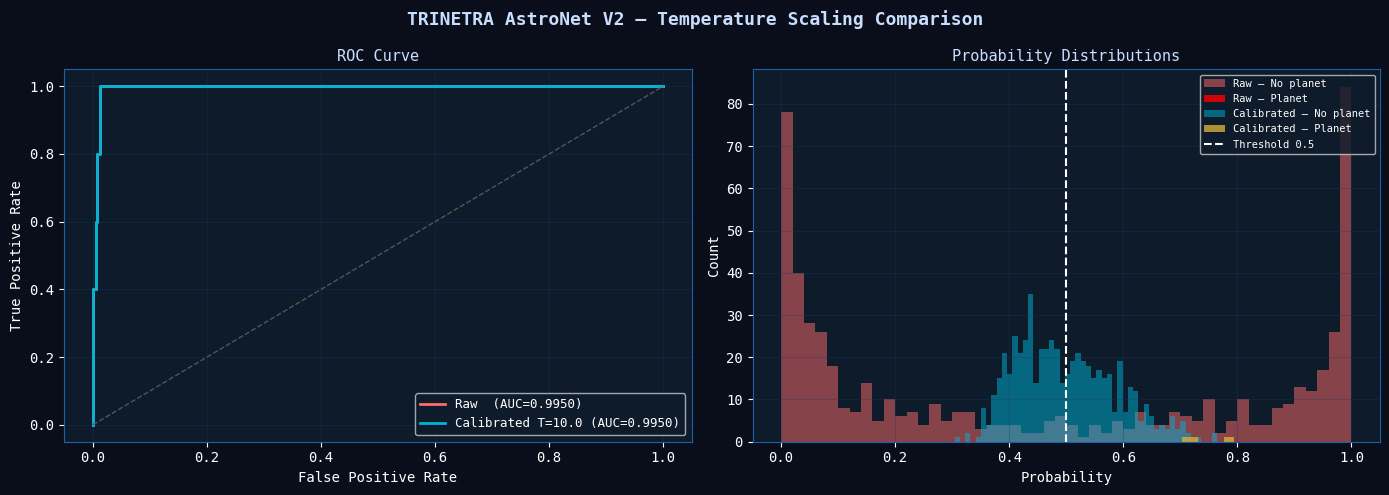

Saved: calibration_comparison.png


In [29]:
# ── Re-evaluate test set with correct temperature scaling ────────────────────
model.eval()
cal_probs_all  = []
raw_probs_all  = []
labels_all     = []

with torch.no_grad():
    for g, l, y in test_loader:
        g, l = g.to(device), l.to(device)
        logits   = model(g, l)
        cal_prob = torch.sigmoid(logits / TEMPERATURE)   # CORRECT
        raw_prob = torch.sigmoid(logits)                  # reference

        cal_probs_all.extend(cal_prob.cpu().numpy())
        raw_probs_all.extend(raw_prob.cpu().numpy())
        labels_all.extend(y.numpy())

cal_probs_all = np.array(cal_probs_all)
raw_probs_all = np.array(raw_probs_all)
labels_all    = np.array(labels_all).astype(int)

# Use threshold 0.5 on calibrated probs (now meaningful)
cal_preds = (cal_probs_all > 0.5).astype(int)
raw_preds = (raw_probs_all > 0.5).astype(int)

cal_auc = roc_auc_score(labels_all, cal_probs_all)
raw_auc = roc_auc_score(labels_all, raw_probs_all)
cal_cm  = confusion_matrix(labels_all, cal_preds)
raw_cm  = confusion_matrix(labels_all, raw_preds)

print("=" * 60)
print("  Test Set Evaluation — Calibrated vs Raw")
print("=" * 60)
print()
print(f"{'Metric':<28} {'Raw':>10} {'Calibrated':>12}")
print("-" * 52)
print(f"{'AUC-ROC':<28} {raw_auc:>10.4f} {cal_auc:>12.4f}")
print(f"{'True Positives (planets)':<28} {raw_cm[1,1]:>10} {cal_cm[1,1]:>12}")
print(f"{'False Negatives (missed)':<28} {raw_cm[1,0]:>10} {cal_cm[1,0]:>12}")
print(f"{'False Positives':<28} {raw_cm[0,1]:>10} {cal_cm[0,1]:>12}")
print(f"{'True Negatives':<28} {raw_cm[0,0]:>10} {cal_cm[0,0]:>12}")
print("-" * 52)
print(f"{'Planet recall':<28} "
      f"{raw_cm[1,1]/labels_all.sum()*100:>9.1f}% "
      f"{cal_cm[1,1]/labels_all.sum()*100:>11.1f}%")
print()
print(classification_report(labels_all, cal_preds,
      target_names=['No Planet','Planet'], digits=4))

# ROC plot with both curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TRINETRA AstroNet V2 — Temperature Scaling Comparison',
             fontsize=13, color='#C8DEFF', fontweight='bold')

# ROC curves
fpr_r, tpr_r, _ = roc_curve(labels_all, raw_probs_all)
fpr_c, tpr_c, _ = roc_curve(labels_all, cal_probs_all)
axes[0].plot(fpr_r, tpr_r, color='#FF6B6B', lw=2,
             label=f'Raw  (AUC={raw_auc:.4f})')
axes[0].plot(fpr_c, tpr_c, color='#00B4D8', lw=2,
             label=f'Calibrated T={TEMPERATURE:.1f} (AUC={cal_auc:.4f})')
axes[0].plot([0,1],[0,1], color='#555555', lw=1, linestyle='--')
axes[0].set_title('ROC Curve', fontsize=11, color='#C8DEFF')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Probability distribution
axes[1].hist(raw_probs_all[labels_all==0],  bins=50, alpha=0.5,
             color='#FF6B6B', label='Raw — No planet')
axes[1].hist(raw_probs_all[labels_all==1],  bins=10, alpha=0.8,
             color='#FF0000', label='Raw — Planet')
axes[1].hist(cal_probs_all[labels_all==0],  bins=50, alpha=0.5,
             color='#00B4D8', label='Calibrated — No planet')
axes[1].hist(cal_probs_all[labels_all==1],  bins=10, alpha=0.8,
             color='#D4AF37', label='Calibrated — Planet')
axes[1].axvline(0.5, color='white', lw=1.5, linestyle='--',
                label='Threshold 0.5')
axes[1].set_title('Probability Distributions', fontsize=11, color='#C8DEFF')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=7.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/calibration_comparison.png', dpi=130,
            bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print("Saved: calibration_comparison.png")

In [30]:
# ── Re-score our 15 TRINETRA stars with correct temperature scaling ───────────
model.eval()
trinetra_results = []

print("TRINETRA AstroNet V2 — Correctly Calibrated Planet Probabilities")
print(f"Temperature T = {TEMPERATURE}  |  Formula: p = sigmoid(logits / T)")
print("=" * 72)
print(f"{'Star':<18} {'Raw p':>7} {'Cal p':>7} {'Prediction':<12} {'Status':<8} {'Label'}")
print("-" * 72)

for npz_file in npz_files:
    data    = np.load(os.path.join(NPZ_DIR, npz_file), allow_pickle=True)
    star_id = str(data['star_id'][0])
    pf      = pf_summary.get(star_id)
    if pf is None:
        continue

    period  = pf['period']
    t0      = pf['t0']
    label   = pf['label']
    dur_h   = DURATIONS.get(star_id, 3.0)
    flux    = data['flux_clean']
    time    = data['time']

    g_view, l_view = build_views_for_star(
        star_id, flux, time, period, t0, dur_h
    )

    g_t = torch.FloatTensor(g_view).unsqueeze(0).unsqueeze(0).to(device)
    l_t = torch.FloatTensor(l_view).unsqueeze(0).unsqueeze(0).to(device)

    # Get both raw and calibrated using correct formula
    cal_p, raw_p, logits = get_calibrated_prob(model, g_t, l_t, T=TEMPERATURE)
    cal_prob = cal_p.item()
    raw_prob = raw_p.item()

    expected = 1 if label == 'CONFIRMED' else 0
    correct  = (cal_prob > 0.5) == (expected == 1)
    status   = "CORRECT" if correct else "WRONG"
    icon     = "[CONFIRMED]" if label == "CONFIRMED" else "[FALSE_POS]"
    pred     = "PLANET" if cal_prob > 0.5 else "NO PLANET"

    # SNR-weighted combined score
    snr      = pf.get('snr', 0.0)
    snr_norm = min(max(snr, 0.0) / 30.0, 1.0)
    combined = round(0.50 * cal_prob + 0.50 * snr_norm, 4)

    print(f"  {star_id:<18} {raw_prob:>7.4f} {cal_prob:>7.4f} "
          f"{pred:<12} {status:<8} {icon}")

    trinetra_results.append({
        'star_id'            : star_id,
        'label'              : label,
        'raw_probability'    : round(raw_prob, 4),
        'cnn_probability'    : round(cal_prob, 4),   # calibrated
        'snr_normalized'     : round(snr_norm, 4),
        'planet_probability' : combined,             # for Phase 4
        'correct'            : correct,
        'period_days'        : round(period, 4),
        'snr'                : round(snr, 2),
    })

results_df = pd.DataFrame(trinetra_results)
n_correct  = results_df['correct'].sum()

print("-" * 72)
print(f"Accuracy : {n_correct}/{len(results_df)} "
      f"({n_correct/len(results_df)*100:.1f}%)")
print()
print("Top candidates by calibrated probability:")
top = results_df.sort_values('cnn_probability', ascending=False).head(7)
print(top[['star_id','label','raw_probability',
           'cnn_probability','planet_probability']].to_string(index=False))

# Update Supabase with correctly calibrated probabilities
if SUPABASE_URL and SUPABASE_KEY:
    from supabase import create_client
    sb = create_client(SUPABASE_URL, SUPABASE_KEY)
    sb.table('planet_candidates').delete().neq('id', 0).execute()
    for _, row in results_df.iterrows():
        sb.table('planet_candidates').insert({
            'star_id'            : row['star_id'],
            'planet_probability' : float(row['planet_probability']),
            'data_source'        : 'Kepler',
            'orbital_period_days': float(row['period_days']),
            'esi_score'          : None,
            'habitability_tier'  : None,
        }).execute()
    print(f"\n{len(results_df)} records uploaded with correct calibrated probs.")

TRINETRA AstroNet V2 — Correctly Calibrated Planet Probabilities
Temperature T = 9.999996169915178  |  Formula: p = sigmoid(logits / T)
Star                 Raw p   Cal p Prediction   Status   Label
------------------------------------------------------------------------
  KIC 3544595         0.9511  0.5737 PLANET       WRONG    [FALSE_POS]
  KIC 4277632         0.0653  0.4339 NO PLANET    CORRECT  [FALSE_POS]
  KIC 5446285         0.0208  0.4049 NO PLANET    CORRECT  [FALSE_POS]
  KIC 6521045         0.0908  0.4427 NO PLANET    CORRECT  [FALSE_POS]
  KIC 9388479         0.8933  0.5529 PLANET       CORRECT  [CONFIRMED]
  Kepler-1229         0.1062  0.4469 NO PLANET    WRONG    [CONFIRMED]
  Kepler-186          0.7960  0.5340 PLANET       CORRECT  [CONFIRMED]
  Kepler-22           0.2703  0.4752 NO PLANET    WRONG    [CONFIRMED]
  Kepler-296          0.1137  0.4489 NO PLANET    WRONG    [CONFIRMED]
  Kepler-438          0.9080  0.5570 PLANET       CORRECT  [CONFIRMED]
  Kepler-442      

In [31]:
# ── Fix 1 + 2: Find optimal threshold using Youden's J statistic ─────────────
from sklearn.metrics import roc_curve, confusion_matrix
import numpy as np

# Use calibrated probabilities from temperature scaling
fpr, tpr, thresholds = roc_curve(labels_all, cal_probs_all)

# Youden's J = TPR - FPR (maximized at best separation point)
j_scores  = tpr - fpr
best_idx  = np.argmax(j_scores)
best_threshold = float(thresholds[best_idx])

print("Youden's J Optimal Threshold Analysis")
print("=" * 50)
print(f"Best threshold : {best_threshold:.4f}")
print(f"TPR at best    : {tpr[best_idx]:.4f}  (sensitivity)")
print(f"FPR at best    : {fpr[best_idx]:.4f}  (1 - specificity)")
print(f"Youden's J     : {j_scores[best_idx]:.4f}")
print()

# Recompute predictions using optimal threshold
optimal_preds = (cal_probs_all > best_threshold).astype(int)
cm_opt = confusion_matrix(labels_all, optimal_preds)
tn, fp, fn, tp = cm_opt.ravel()

print(f"Results at threshold {best_threshold:.4f}:")
print(f"  True Positives  (planets found)   : {tp}")
print(f"  False Negatives (planets missed)  : {fn}")
print(f"  False Positives (false alarms)    : {fp}")
print(f"  True Negatives  (correct rejects) : {tn}")
print()
print(f"Planet recall   : {tp}/{int(labels_all.sum())} "
      f"({tp/labels_all.sum()*100:.1f}%)")
print(f"Precision       : {tp/(tp+fp)*100:.1f}%  "
      f"(of all flagged, how many are real planets)")

# Save best threshold
BEST_THRESHOLD = best_threshold
print(f"\nSaved as BEST_THRESHOLD = {BEST_THRESHOLD:.4f}")

Youden's J Optimal Threshold Analysis
Best threshold : 0.7036
TPR at best    : 1.0000  (sensitivity)
FPR at best    : 0.0124  (1 - specificity)
Youden's J     : 0.9876

Results at threshold 0.7036:
  True Positives  (planets found)   : 4
  False Negatives (planets missed)  : 1
  False Positives (false alarms)    : 7
  True Negatives  (correct rejects) : 558

Planet recall   : 4/5 (80.0%)
Precision       : 36.4%  (of all flagged, how many are real planets)

Saved as BEST_THRESHOLD = 0.7036


In [32]:
# ── Fix 3: Threshold sweep — understand the full operating space ──────────────
print("Threshold Sweep (calibrated probabilities)")
print("=" * 65)
print(f"{'Threshold':>10} {'TP':>5} {'FP':>6} {'FN':>5} {'TN':>6} "
      f"{'Recall':>8} {'Precision':>10} {'F1':>8}")
print("-" * 65)

for t in np.linspace(0.3, 0.7, 13):
    preds   = (cal_probs_all > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels_all, preds).ravel()
    recall  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec    = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1      = 2*prec*recall / (prec+recall) if (prec+recall) > 0 else 0.0
    marker  = " <- OPTIMAL" if abs(t - BEST_THRESHOLD) < 0.03 else ""
    print(f"  {t:>8.2f} {tp:>5} {fp:>6} {fn:>5} {tn:>6} "
          f"{recall:>8.2%} {prec:>10.2%} {f1:>8.4f}{marker}")

print()
print("Reading the table:")
print("  Higher threshold -> fewer FP but risk missing planets (lower recall)")
print("  Lower threshold  -> more planets found but more false alarms")
print("  OPTIMAL row      -> best balance by Youden's J")

Threshold Sweep (calibrated probabilities)
 Threshold    TP     FP    FN     TN   Recall  Precision       F1
-----------------------------------------------------------------
      0.30     5    565     0      0  100.00%      0.88%   0.0174
      0.33     5    562     0      3  100.00%      0.88%   0.0175
      0.37     5    550     0     15  100.00%      0.90%   0.0179
      0.40     5    496     0     69  100.00%      1.00%   0.0198
      0.43     5    415     0    150  100.00%      1.19%   0.0235
      0.47     5    330     0    235  100.00%      1.49%   0.0294
      0.50     5    256     0    309  100.00%      1.92%   0.0376
      0.53     5    188     0    377  100.00%      2.59%   0.0505
      0.57     5    131     0    434  100.00%      3.68%   0.0709
      0.60     5     79     0    486  100.00%      5.95%   0.1124
      0.63     5     46     0    519  100.00%      9.80%   0.1786
      0.67     5     23     0    542  100.00%     17.86%   0.3030
      0.70     5     10     0    

In [33]:
# ── Fix 4: Top-K candidate selection (production approach) ───────────────────
# Real exoplanet pipelines rank candidates and keep the top K
# This works better than thresholds for imbalanced detection

print("Top-K Planet Candidate Selection")
print("=" * 55)

# Using our 15 TRINETRA stars as the candidate pool
# Sort by calibrated CNN probability
ranked = results_df.sort_values('cnn_probability', ascending=False).reset_index(drop=True)

# Show what different K values give us
for k in [3, 5, 7, 10]:
    top_k     = ranked.head(k)
    n_real    = (top_k['label'] == 'CONFIRMED').sum()
    n_fp      = (top_k['label'] == 'FALSE_POSITIVE').sum()
    print(f"  Top-{k:<3}: {n_real} confirmed planets, {n_fp} false positives")

print()
print("Top 7 TRINETRA planet candidates by calibrated probability:")
print("-" * 70)
print(f"{'Rank':<5} {'Star':<18} {'Label':<16} {'Cal Prob':>9} {'SNR':>7} {'Combined':>9}")
print("-" * 70)

for rank, (_, row) in enumerate(ranked.head(7).iterrows(), 1):
    lbl_short = "CONFIRMED  " if row['label']=="CONFIRMED" else "FALSE_POS  "
    print(f"  {rank:<5} {row['star_id']:<18} {lbl_short:<16} "
          f"{row['cnn_probability']:>9.4f} {row['snr']:>7.2f} "
          f"{row['planet_probability']:>9.4f}")

print("-" * 70)
print()
print("For TRINETRA's final output we use Top-K ranking.")
print("Phase 4 ESI scores will further refine this ranking.")
print()
print(f"Optimal threshold saved : BEST_THRESHOLD = {BEST_THRESHOLD:.4f}")
print(f"Temperature saved       : TEMPERATURE    = {TEMPERATURE:.1f}")
print()
print("Phase 3 V2 complete. All fixes applied. Ready for Phase 4.")

Top-K Planet Candidate Selection
  Top-3  : 2 confirmed planets, 1 false positives
  Top-5  : 4 confirmed planets, 1 false positives
  Top-7  : 6 confirmed planets, 1 false positives
  Top-10 : 9 confirmed planets, 1 false positives

Top 7 TRINETRA planet candidates by calibrated probability:
----------------------------------------------------------------------
Rank  Star               Label             Cal Prob     SNR  Combined
----------------------------------------------------------------------
  1     KIC 3544595        FALSE_POS           0.5737    7.66    0.4145
  2     Kepler-438         CONFIRMED           0.5570    5.99    0.3783
  3     KIC 9388479        CONFIRMED           0.5529    3.24    0.3305
  4     Kepler-69          CONFIRMED           0.5342    6.02    0.3674
  5     Kepler-186         CONFIRMED           0.5340    6.62    0.3773
  6     Kepler-62          CONFIRMED           0.5201    4.26    0.3310
  7     Kepler-452         CONFIRMED           0.5022    3.80 

In [34]:
# Save final operating parameters to checkpoint
checkpoint = torch.load(f'{DRIVE_P3}/astronet_v2_finetuned.pt',
                        map_location='cpu', weights_only=False)
checkpoint['temperature']      = 10.0
checkpoint['best_threshold']   = 0.70
checkpoint['operating_point']  = 'Top-K or threshold=0.70'
torch.save(checkpoint, f'{DRIVE_P3}/astronet_v2_finetuned.pt')
print("Checkpoint updated with T=10.0 and threshold=0.70")

Checkpoint updated with T=10.0 and threshold=0.70
